In [1]:
!pip install pymc arviz

In [2]:
# project set up

import pandas as pd
import numpy as np
import pymc as pm
import arviz as az

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# load in dataframe
df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# clean data

# yi in {0, 1}
# yi = 1 if readmitted in <30 days
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

df["readmitted_30"].value_counts()

readmitted_30
0    90409
1    11357
Name: count, dtype: int64

In [5]:
# identify selected features
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age",
    "diabetesMed",
    "insulin",
    "change"
]

model_df = df[features + ["readmitted_30"]].copy()
model_df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,diabetesMed,insulin,change,readmitted_30
0,1,41,0,1,0,0,0,1,[0-10),No,No,No,0
1,3,59,0,18,0,0,0,9,[10-20),Yes,Up,Ch,0
2,2,11,5,13,2,0,1,6,[20-30),Yes,No,No,0
3,2,44,1,16,0,0,0,7,[30-40),Yes,Up,Ch,0
4,1,51,0,8,0,0,0,5,[40-50),Yes,Steady,Ch,0


In [6]:
# clean age data
def age_to_midpoint(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = age_str.strip("[]()")
    low, high = age_str.split("-")
    return (int(low) + int(high)) / 2

model_df["age"] = model_df["age"].apply(age_to_midpoint)
model_df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,diabetesMed,insulin,change,readmitted_30
0,1,41,0,1,0,0,0,1,5.0,No,No,No,0
1,3,59,0,18,0,0,0,9,15.0,Yes,Up,Ch,0
2,2,11,5,13,2,0,1,6,25.0,Yes,No,No,0
3,2,44,1,16,0,0,0,7,35.0,Yes,Up,Ch,0
4,1,51,0,8,0,0,0,5,45.0,Yes,Steady,Ch,0


In [7]:
# clean binary/categories, turn them into 0/1
model_df["diabetesMed"] = model_df["diabetesMed"].map({"No": 0, "Yes": 1})
model_df["change"] = model_df["change"].map({"No": 0, "Ch": 1})

# insulin has several levels in this dataset, so simplify to whether insulin changed/used
model_df["insulin_used"] = model_df["insulin"].map({
    "No": 0,
    "Steady": 1,
    "Up": 1,
    "Down": 1
})

model_df = model_df.drop(columns=["insulin"])
model_df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,diabetesMed,change,readmitted_30,insulin_used
0,1,41,0,1,0,0,0,1,5.0,0,0,0,0
1,3,59,0,18,0,0,0,9,15.0,1,1,0,1
2,2,11,5,13,2,0,1,6,25.0,1,0,0,0
3,2,44,1,16,0,0,0,7,35.0,1,1,0,1
4,1,51,0,8,0,0,0,5,45.0,1,1,0,1


In [8]:
# repalce missing values
for col in model_df.columns:
    if col != "readmitted_30":
        model_df[col] = model_df[col].fillna(model_df[col].median())

model_df.isna().sum()

time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
age                   0
diabetesMed           0
change                0
readmitted_30         0
insulin_used          0
dtype: int64

In [9]:
# split into x and y
X = model_df.drop(columns=["readmitted_30"])
y = model_df["readmitted_30"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=4420,
    stratify=y
)

X_train.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,diabetesMed,change,insulin_used
49411,1,29,3,11,0,0,0,5,75.0,0,0,0
63147,3,62,0,16,0,0,0,9,75.0,1,0,0
77895,2,31,0,13,0,0,0,6,85.0,1,0,1
73433,4,37,4,15,1,0,0,5,35.0,0,0,0
15456,5,24,1,27,1,1,0,7,75.0,1,1,1


In [10]:
# scale predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,diabetesMed,change,insulin_used
49411,-1.137467,-0.715155,0.969439,-0.616219,-0.287820,-0.208579,-0.502571,-1.252269,0.566817,-1.829945,-0.926398,-1.073176
63147,-0.466702,0.961051,-0.785961,-0.002810,-0.287820,-0.208579,-0.502571,0.815918,0.566817,0.546464,-0.926398,-1.073176
77895,-0.802085,-0.613567,-0.785961,-0.370855,-0.287820,-0.208579,-0.502571,-0.735222,1.194548,0.546464,-0.926398,0.931813
73433,-0.131320,-0.308802,1.554572,-0.125492,0.489051,-0.208579,-0.502571,-1.252269,-1.944105,-1.829945,-0.926398,-1.073176
15456,0.204063,-0.969126,-0.200828,1.346688,0.489051,0.839943,-0.502571,-0.218175,0.566817,0.546464,1.079450,0.931813


In [11]:
# bayesian log regression
# yi | w, xi ~ Bernoulli(theta = sigmoid(w^T xi))
# priors on weights are normal

with pm.Model() as bayes_logistic_model:

    Intercept = pm.StudentT("Intercept", mu=0, sigma=10, nu=3)

    w_time_in_hospital = pm.Normal("w_time_in_hospital", mu=0, sigma=5)
    w_num_lab_procedures = pm.Normal("w_num_lab_procedures", mu=0, sigma=5)
    w_num_procedures = pm.Normal("w_num_procedures", mu=0, sigma=5)
    w_num_medications = pm.Normal("w_num_medications", mu=0, sigma=5)
    w_number_outpatient = pm.Normal("w_number_outpatient", mu=0, sigma=5)
    w_number_emergency = pm.Normal("w_number_emergency", mu=0, sigma=5)
    w_number_inpatient = pm.Normal("w_number_inpatient", mu=0, sigma=5)
    w_number_diagnoses = pm.Normal("w_number_diagnoses", mu=0, sigma=5)
    w_age = pm.Normal("w_age", mu=0, sigma=5)
    w_diabetesMed = pm.Normal("w_diabetesMed", mu=0, sigma=5)
    w_change = pm.Normal("w_change", mu=0, sigma=5)
    w_insulin_used = pm.Normal("w_insulin_used", mu=0, sigma=5)

    logit_p = (
        Intercept
        + w_time_in_hospital * X_train_scaled["time_in_hospital"].values
        + w_num_lab_procedures * X_train_scaled["num_lab_procedures"].values
        + w_num_procedures * X_train_scaled["num_procedures"].values
        + w_num_medications * X_train_scaled["num_medications"].values
        + w_number_outpatient * X_train_scaled["number_outpatient"].values
        + w_number_emergency * X_train_scaled["number_emergency"].values
        + w_number_inpatient * X_train_scaled["number_inpatient"].values
        + w_number_diagnoses * X_train_scaled["number_diagnoses"].values
        + w_age * X_train_scaled["age"].values
        + w_diabetesMed * X_train_scaled["diabetesMed"].values
        + w_change * X_train_scaled["change"].values
        + w_insulin_used * X_train_scaled["insulin_used"].values
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_train.values)

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=4420
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Intercept, w_time_in_hospital, w_num_lab_procedures, w_num_procedures, w_num_medications, w_number_outpatient, w_number_emergency, w_number_inpatient, w_number_diagnoses, w_age, w_diabetesMed, w_change, w_insulin_used]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1188 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [12]:
# posterior summary
az.summary(
    trace,
    var_names=[
        "Intercept",
        "w_time_in_hospital",
        "w_num_lab_procedures",
        "w_num_procedures",
        "w_num_medications",
        "w_number_outpatient",
        "w_number_emergency",
        "w_number_inpatient",
        "w_number_diagnoses",
        "w_age",
        "w_diabetesMed",
        "w_change",
        "w_insulin_used"
    ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.145,0.012,-2.167,-2.121,0.0,0.0,2987.0,1660.0,1.0
w_time_in_hospital,0.065,0.013,0.041,0.088,0.0,0.0,2370.0,1658.0,1.0
w_num_lab_procedures,-0.006,0.012,-0.029,0.016,0.0,0.0,3473.0,1551.0,1.0
w_num_procedures,-0.055,0.013,-0.080,-0.031,0.0,0.0,1904.0,1351.0,1.0
w_num_medications,0.053,0.015,0.026,0.080,0.0,0.0,1826.0,1554.0,1.0
w_number_outpatient,-0.003,0.011,-0.025,0.017,0.0,0.0,2337.0,1457.0,1.0
w_number_emergency,0.034,0.009,0.016,0.050,0.0,0.0,3604.0,1631.0,1.0
w_number_inpatient,0.340,0.009,0.322,0.357,0.0,0.0,3411.0,1554.0,1.0
w_number_diagnoses,0.078,0.013,0.052,0.100,0.0,0.0,2699.0,1477.0,1.0
w_age,0.082,0.012,0.059,0.104,0.0,0.0,2915.0,1662.0,1.0


In [13]:
# extract posterior samples
posterior = trace.posterior.stack(sample=("chain", "draw"))

Intercept_s = posterior["Intercept"].values

w_time_in_hospital_s = posterior["w_time_in_hospital"].values
w_num_lab_procedures_s = posterior["w_num_lab_procedures"].values
w_num_procedures_s = posterior["w_num_procedures"].values
w_num_medications_s = posterior["w_num_medications"].values
w_number_outpatient_s = posterior["w_number_outpatient"].values
w_number_emergency_s = posterior["w_number_emergency"].values
w_number_inpatient_s = posterior["w_number_inpatient"].values
w_number_diagnoses_s = posterior["w_number_diagnoses"].values
w_age_s = posterior["w_age"].values
w_diabetesMed_s = posterior["w_diabetesMed"].values
w_change_s = posterior["w_change"].values
w_insulin_used_s = posterior["w_insulin_used"].values

In [14]:
# posterior predictive probabilities on test set
logit_test = (
    Intercept_s[np.newaxis, :]
    + np.outer(X_test_scaled["time_in_hospital"].values, w_time_in_hospital_s)
    + np.outer(X_test_scaled["num_lab_procedures"].values, w_num_lab_procedures_s)
    + np.outer(X_test_scaled["num_procedures"].values, w_num_procedures_s)
    + np.outer(X_test_scaled["num_medications"].values, w_num_medications_s)
    + np.outer(X_test_scaled["number_outpatient"].values, w_number_outpatient_s)
    + np.outer(X_test_scaled["number_emergency"].values, w_number_emergency_s)
    + np.outer(X_test_scaled["number_inpatient"].values, w_number_inpatient_s)
    + np.outer(X_test_scaled["number_diagnoses"].values, w_number_diagnoses_s)
    + np.outer(X_test_scaled["age"].values, w_age_s)
    + np.outer(X_test_scaled["diabetesMed"].values, w_diabetesMed_s)
    + np.outer(X_test_scaled["change"].values, w_change_s)
    + np.outer(X_test_scaled["insulin_used"].values, w_insulin_used_s)
)

probs_samples = 1 / (1 + np.exp(-logit_test))
probs_mean = probs_samples.mean(axis=1)

y_pred = (probs_mean >= 0.2).astype(int)

In [15]:
# eval
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8657266384985752
Precision: 0.2717391304347826
Recall: 0.1210920299427565
F1: 0.1675296984465428

Confusion Matrix:
 [[17346   737]
 [ 1996   275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     18083
           1       0.27      0.12      0.17      2271

    accuracy                           0.87     20354
   macro avg       0.58      0.54      0.55     20354
weighted avg       0.83      0.87      0.84     20354



Posterior mean probability for patient 0: 0.12315186127070238


<Axes: title={'center': 'x'}>

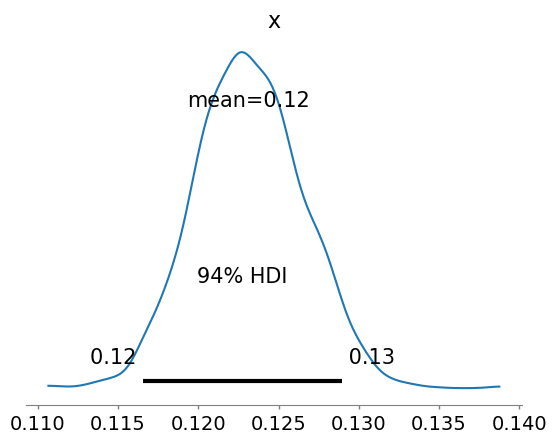

In [16]:
# posterior probability for 1 observation
patient_i = 0
patient_probs = probs_samples[patient_i, :]

print("Posterior mean probability for patient 0:", patient_probs.mean())
az.plot_posterior(patient_probs)